Running CONTINUOUS (parallel) simulations...

n=4, alpha=2 -> frequency = 0.0494
n=4, alpha=3 -> frequency = 0.0335
n=4, alpha=4 -> frequency = 0.0000
n=4, alpha=5 -> frequency = 0.0000
n=4, alpha=6 -> frequency = 0.0000
n=4, alpha=7 -> frequency = 0.0000
n=4, alpha=8 -> frequency = 0.0000
n=4, alpha=9 -> frequency = 0.0000
n=5, alpha=2 -> frequency = 0.2339
n=5, alpha=3 -> frequency = 0.2802
n=5, alpha=4 -> frequency = 0.1991
n=5, alpha=5 -> frequency = 0.1369
n=5, alpha=6 -> frequency = 0.0850
n=5, alpha=7 -> frequency = 0.0728
n=5, alpha=8 -> frequency = 0.0657
n=5, alpha=9 -> frequency = 0.0316
n=6, alpha=2 -> frequency = 0.4106
n=6, alpha=3 -> frequency = 0.4932
n=6, alpha=4 -> frequency = 0.4387
n=6, alpha=5 -> frequency = 0.3773
n=6, alpha=6 -> frequency = 0.3180
n=6, alpha=7 -> frequency = 0.2605
n=6, alpha=8 -> frequency = 0.2255
n=6, alpha=9 -> frequency = 0.1918
n=7, alpha=2 -> frequency = 0.5781
n=7, alpha=3 -> frequency = 0.6582
n=7, alpha=4 -> frequency = 0.6251
n=7, alph

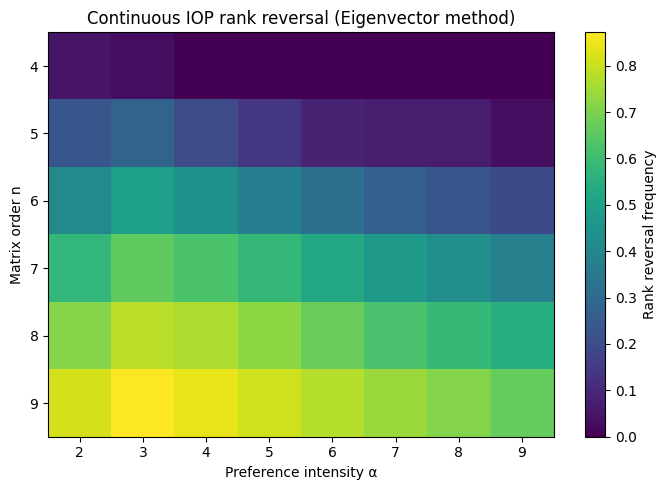

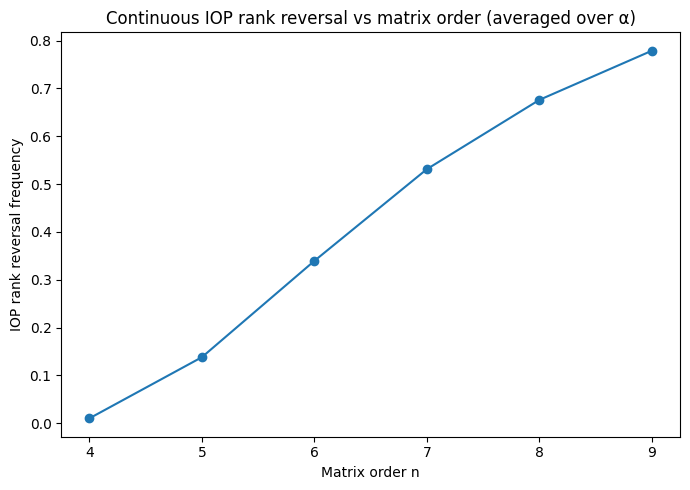

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Generate ordinal PCM (same as discrete)
# =========================================================

def random_ordinal_pcm(n):
    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):
            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1
            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"
            else:
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A

# =========================================================
# 4. Substitute alpha (same as discrete)
# =========================================================

def substitute_alpha(A_ord, alpha):
    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):
            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A

# =========================================================
# 5. Continuous intensification experiment
# =========================================================

def continuous_iop_frequency(n, alpha, k=2, trials=10000, tol=1e-10):

    reversals = 0

    for _ in range(trials):

        # Step 1: fixed ordinal structure
        A_ord = random_ordinal_pcm(n)

        # Step 2: construct A(alpha)
        A = substitute_alpha(A_ord, alpha)

        # Step 3: continuous intensification
        Ak = A ** k

        # Step 4: compute rankings
        wA = eigenvector_priority(A)
        wAk = eigenvector_priority(Ak)

        rA = ranking_with_ties(wA, tol)
        rAk = ranking_with_ties(wAk, tol)

        if not np.array_equal(rA, rAk):
            reversals += 1

    return reversals / trials

# =========================================================
# 6. Run simulations
# =========================================================

np.random.seed(42)

n_values = [4, 5, 6, 7, 8, 9]
alpha_values = list(range(2, 10))  # α = 2,...,9

k = 2
trials = 10000

results = []

print("Running CONTINUOUS (parallel) simulations...\n")

for n in n_values:
    for alpha in alpha_values:

        freq = continuous_iop_frequency(
            n=n,
            alpha=alpha,
            k=k,
            trials=trials
        )

        results.append((n, alpha, freq))
        print(f"n={n}, alpha={alpha} -> frequency = {freq:.4f}")

# =========================================================
# 7. Results table
# =========================================================

df = pd.DataFrame(results, columns=["n", "alpha", "frequency"])
pivot = df.pivot(index="n", columns="alpha", values="frequency")

print("\nEstimated frequency of continuous IOP rank reversal:\n")
print(pivot.round(4))

# =========================================================
# 8. Heatmap
# =========================================================

plt.figure(figsize=(7, 5))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Rank reversal frequency")

plt.xticks(range(len(alpha_values)), alpha_values)
plt.yticks(range(len(n_values)), n_values)

plt.xlabel("Preference intensity α")
plt.ylabel("Matrix order n")
plt.title("Continuous IOP rank reversal (Eigenvector method)")

plt.tight_layout()

plt.savefig(
    "continuous_iop_heatmap.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Aggregated frequency vs n
# =========================================================

avg_over_alpha = pivot.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(n_values, avg_over_alpha.loc[n_values], marker="o")

plt.xlabel("Matrix order n")
plt.ylabel("IOP rank reversal frequency")
plt.title("Continuous IOP rank reversal vs matrix order (averaged over α)")

plt.xticks(n_values)
plt.tight_layout()

plt.savefig(
    "continuous_iop_vs_n.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



Running CONTINUOUS CR bin analysis for n=7, alpha=3...


Number of matrices per CR group:

CR_group
CR < 0.05              0
0.05 ≤ CR < 0.10      79
0.10 ≤ CR < 0.15     574
CR ≥ 0.15           9347
Name: count, dtype: int64

Rank reversal frequency by CR group:

CR_group
0.05 ≤ CR < 0.10    0.291139
0.10 ≤ CR < 0.15    0.466899
CR ≥ 0.15           0.673799
Name: Reversal, dtype: float64


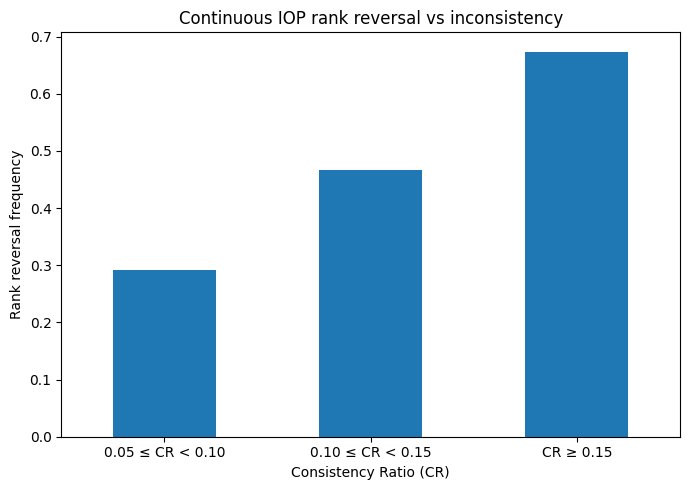


Figure saved to: continuous\continuous_iop_rank_reversal_vs_inconsistency.jpeg


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Random reciprocal PCM generator
# =========================================================

def random_pcm(n, alpha):
    A = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            value = np.random.choice([1, alpha, 1/alpha])
            A[i, j] = value
            A[j, i] = 1 / value
    return A

# =========================================================
# 4. Consistency Ratio (Saaty)
# =========================================================

def consistency_ratio(A):

    n = A.shape[0]

    RI_table = {
        1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
        6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49
    }

    eigenvalues, _ = eig(A)
    lambda_max = np.max(eigenvalues.real)

    CI = (lambda_max - n) / (n - 1)
    RI = RI_table[n]

    if RI == 0:
        return 0.0

    return CI / RI

# =========================================================
# 5. Monte Carlo simulation storing CR and reversals
# =========================================================

def simulate_reversals_with_cr(n, alpha, k=2, trials=10000, tol=1e-10):

    records = []

    for _ in range(trials):

        A = random_pcm(n, alpha)
        Ak = A ** k

        cr = consistency_ratio(A)

        wA = eigenvector_priority(A)
        wAk = eigenvector_priority(Ak)

        rA = ranking_with_ties(wA, tol)
        rAk = ranking_with_ties(wAk, tol)

        reversal = int(not np.array_equal(rA, rAk))

        records.append((cr, reversal))

    return pd.DataFrame(records, columns=["CR", "Reversal"])

# =========================================================
# 6. Output folder
# =========================================================

output_dir = "continuous"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 7. Run experiment
# =========================================================

np.random.seed(42)

n = 7
alpha = 3
k = 2
trials = 10000

print(f"Running CONTINUOUS CR bin analysis for n={n}, alpha={alpha}...\n")

df = simulate_reversals_with_cr(n, alpha, k, trials)

# Save raw data
raw_path = os.path.join(output_dir, "continuous_cr_analysis.xlsx")
df.to_excel(raw_path, index=False)

# =========================================================
# 8. Improved CR bins (adapted to observed range)
# =========================================================

bins = [0.0, 0.05, 0.10, 0.15, np.inf]
labels = [
    "CR < 0.05",
    "0.05 ≤ CR < 0.10",
    "0.10 ≤ CR < 0.15",
    "CR ≥ 0.15"
]

df["CR_group"] = pd.cut(df["CR"], bins=bins, labels=labels)

# Count per group
print("\nNumber of matrices per CR group:\n")
print(df["CR_group"].value_counts().sort_index())

# Reversal frequency per group
summary = df.groupby("CR_group", observed=False)["Reversal"].mean().dropna()

print("\nRank reversal frequency by CR group:\n")
print(summary)

# Save summary
summary_path = os.path.join(output_dir, "continuous_cr_summary.xlsx")
summary.reset_index().to_excel(summary_path, index=False)

# =========================================================
# 9. Bar plot
# =========================================================

plt.figure(figsize=(7, 5))
summary.plot(kind="bar")

plt.xlabel("Consistency Ratio (CR)")
plt.ylabel("Rank reversal frequency")
plt.title("Continuous IOP rank reversal vs inconsistency")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    "continuous_iop_rank_reversal_vs_inconsistency.jpeg"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigure saved to: {figure_path}")



In [6]:
#tercera parte


Running TRUE CONTINUOUS IOP experiment...

Eigenvector        | n=4 -> 0.1347
Eigenvector        | n=5 -> 0.3617
Eigenvector        | n=6 -> 0.6123
Eigenvector        | n=7 -> 0.7827
Eigenvector        | n=8 -> 0.8790
Geometric mean     | n=4 -> 0.0000
Geometric mean     | n=5 -> 0.0000
Geometric mean     | n=6 -> 0.0000
Geometric mean     | n=7 -> 0.0000
Geometric mean     | n=8 -> 0.0000
Row sum            | n=4 -> 0.2077
Row sum            | n=5 -> 0.4117
Row sum            | n=6 -> 0.5910
Row sum            | n=7 -> 0.7537
Row sum            | n=8 -> 0.8673
Column sum         | n=4 -> 0.2233
Column sum         | n=5 -> 0.4250
Column sum         | n=6 -> 0.6157
Column sum         | n=7 -> 0.7577
Column sum         | n=8 -> 0.8593
Harmonic mean      | n=4 -> 0.2013
Harmonic mean      | n=5 -> 0.4243
Harmonic mean      | n=6 -> 0.5987
Harmonic mean      | n=7 -> 0.7643
Harmonic mean      | n=8 -> 0.8507
Cosine max         | n=4 -> 0.2923
Cosine max         | n=5 -> 0.5483
Cosine max 

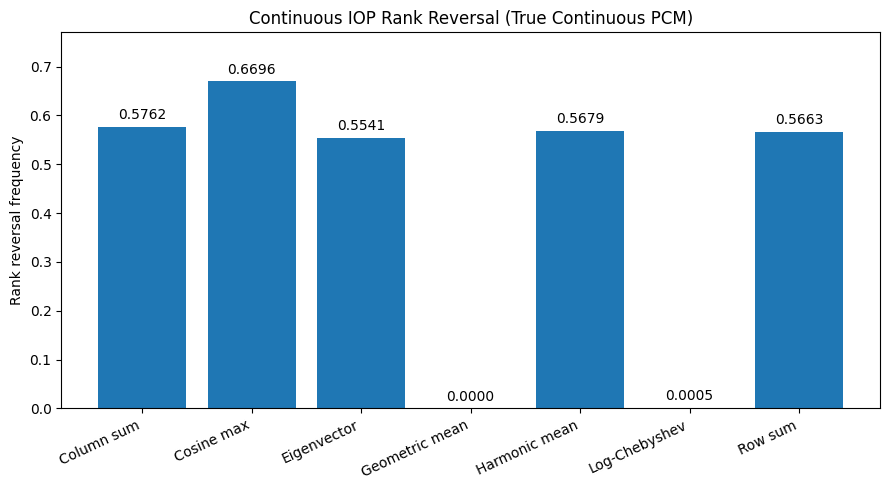

Figure saved to: continuous_results\continuous_iop_barplot_values.jpeg


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig
from scipy.optimize import linprog

# =========================================================
# 1. Priority derivation methods (7 methods)
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)


def geometric_mean_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    return gm / np.sum(gm)


def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return rs / np.sum(rs)


def column_sum_priority(A):
    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.sum(norm_matrix, axis=1)
    return w / np.sum(w)


def harmonic_mean_priority(A):
    hm = 1 / np.sum(1 / A, axis=1)
    return hm / np.sum(hm)


def cosine_maximization_priority(A):
    n = A.shape[0]
    b = np.zeros_like(A)

    for j in range(n):
        denom = np.sum(A[:, j] ** 2)
        for i in range(n):
            b[i, j] = A[i, j] / denom

    s = np.sum(b, axis=1)
    return s / np.sum(s)


def log_chebyshev_priority(A):
    """
    Log-Chebyshev (Minimax) method via LP
    Stabilized by fixing x_0 = 0
    """
    n = A.shape[0]
    logA = np.log(A)

    num_vars = n + 1  # x_1,...,x_n,t
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:
                # -(x_i - x_j) - t <= -logA_ij
                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                # (x_i - x_j) - t <= logA_ij
                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # Objective: minimize t
    c = np.zeros(num_vars)
    c[-1] = 1

    # Fix translation invariance: x_0 = 0
    A_eq = np.zeros((1, num_vars))
    A_eq[0, 0] = 1
    b_eq = np.array([0.0])

    res = linprog(c,
                  A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds,
                  method="highs")

    if not res.success:
        return None

    x = res.x[:n]
    w = np.exp(x)
    return w / np.sum(w)


# =========================================================
# 2. Ranking with tolerance
# =========================================================

def ranking(weights, tol=1e-8):
    order = np.argsort(-weights)
    ranks = np.zeros(len(weights), dtype=int)

    rank = 1
    ranks[order[0]] = rank

    for i in range(1, len(weights)):
        if abs(weights[order[i]] - weights[order[i-1]]) > tol:
            rank += 1
        ranks[order[i]] = rank

    return ranks


# =========================================================
# 3. Truly continuous random PCM generator
# =========================================================

def random_pcm_continuous(n, alpha_min=1.2, alpha_max=9.0):
    """
    Continuous reciprocal PCM with random intensities in [alpha_min, alpha_max]
    """
    A = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):

            r = np.random.rand()

            if r < 1/3:
                value = 1.0
            elif r < 2/3:
                value = np.random.uniform(alpha_min, alpha_max)
            else:
                value = 1 / np.random.uniform(alpha_min, alpha_max)

            A[i, j] = value
            A[j, i] = 1 / value

    return A


# =========================================================
# 4. Rank reversal frequency under exponentiation A^k
# =========================================================

def rank_reversal_frequency(method, n,
                            k=2,
                            trials=3000):

    reversals = 0
    valid_trials = 0

    for _ in range(trials):

        A = random_pcm_continuous(n)
        Ak = A ** k

        wA = method(A)
        wAk = method(Ak)

        if wA is None or wAk is None:
            continue

        rA = ranking(wA)
        rAk = ranking(wAk)

        valid_trials += 1

        if not np.array_equal(rA, rAk):
            reversals += 1

    return reversals / valid_trials


# =========================================================
# 5. Run Monte Carlo comparison
# =========================================================

np.random.seed(42)

methods = {
    "Eigenvector": eigenvector_priority,
    "Geometric mean": geometric_mean_priority,
    "Row sum": row_sum_priority,
    "Column sum": column_sum_priority,
    "Harmonic mean": harmonic_mean_priority,
    "Cosine max": cosine_maximization_priority,
    "Log-Chebyshev": log_chebyshev_priority
}

n_values = [4, 5, 6, 7, 8]
k = 2
trials = 3000

records = []

print("\nRunning TRUE CONTINUOUS IOP experiment...\n")

for name, method in methods.items():
    for n in n_values:

        freq = rank_reversal_frequency(
            method=method,
            n=n,
            k=k,
            trials=trials
        )

        records.append((name, n, freq))
        print(f"{name:18s} | n={n} -> {freq:.4f}")

# =========================================================
# 6. Summary results
# =========================================================

df = pd.DataFrame(records,
                  columns=["Method", "n", "Frequency"])

summary = df.groupby("Method")["Frequency"].mean()

print("\nMean continuous IOP rank reversal frequency:\n")
print(summary)

# =========================================================
# 7. Save results
# =========================================================

output_dir = "continuous_results"
os.makedirs(output_dir, exist_ok=True)

excel_path = os.path.join(output_dir,
                          "continuous_iop_results.xlsx")

df.to_excel(excel_path, index=False)

print("\nResults saved to:", excel_path)

# =========================================================
# 8. Bar plot (linear scale + values above bars)
# =========================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(summary.index, summary.values)

plt.ylabel("Rank reversal frequency")
plt.title("Continuous IOP Rank Reversal (True Continuous PCM)")

# Add numerical values above bars
for bar, val in zip(bars, summary.values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, max(summary.values) * 1.15)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

figure_path = os.path.join(output_dir,
                           "continuous_iop_barplot_values.jpeg")

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)



In [9]:
#experimento chevichev

In [10]:
import numpy as np
from scipy.optimize import linprog

# =========================================================
# Log-Chebyshev priority (LP minimax)
# =========================================================
def log_chebyshev_priority(A):
    n = A.shape[0]
    logA = np.log(A)

    # Variables: x_1,...,x_n,t
    num_vars = n + 1
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:
                # -(x_i - x_j) - t <= -logA_ij
                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                # (x_i - x_j) - t <= logA_ij
                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # Objective: minimize t
    c = np.zeros(num_vars)
    c[-1] = 1

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                  bounds=bounds, method="highs")

    if not res.success:
        return None

    x = res.x[:n]
    w = np.exp(x)
    return w / np.sum(w)


# =========================================================
# Ranking function with tolerance
# =========================================================
def ranking(weights, tol=1e-8):
    order = np.argsort(-weights)
    ranks = np.zeros(len(weights), dtype=int)

    rank = 1
    ranks[order[0]] = rank

    for i in range(1, len(weights)):
        if abs(weights[order[i]] - weights[order[i-1]]) > tol:
            rank += 1
        ranks[order[i]] = rank

    return ranks


# =========================================================
# Continuous random PCM generator
# =========================================================
def random_pcm_continuous(n, alpha_min=1.2, alpha_max=9.0):
    """
    Generate reciprocal PCM with random intensities in [alpha_min, alpha_max]
    """
    A = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):

            r = np.random.rand()

            if r < 1/3:
                value = 1.0
            elif r < 2/3:
                value = np.random.uniform(alpha_min, alpha_max)
            else:
                value = 1 / np.random.uniform(alpha_min, alpha_max)

            A[i, j] = value
            A[j, i] = 1 / value

    return A


# =========================================================
# Main experiment: detect rank reversal for LCM
# =========================================================
def experiment_LCM(n=7, trials=2000, k_values=[1.5, 2, 3, 4]):
    reversals = 0
    examples = []

    for t in range(trials):

        A = random_pcm_continuous(n)

        wA = log_chebyshev_priority(A)
        if wA is None:
            continue

        rA = ranking(wA)

        for k in k_values:
            Ak = A ** k
            wAk = log_chebyshev_priority(Ak)

            if wAk is None:
                continue

            rAk = ranking(wAk)

            if not np.array_equal(rA, rAk):
                reversals += 1

                # Save one example
                if len(examples) < 5:
                    examples.append((A, k, rA, rAk))

                break

    print("\n==========================================")
    print("Log-Chebyshev Continuous Rank Reversal Test")
    print("==========================================")
    print(f"Matrix size n        = {n}")
    print(f"Trials               = {trials}")
    print(f"k values tested      = {k_values}")
    print("------------------------------------------")
    print(f"Reversals detected   = {reversals}")
    print(f"Frequency            = {reversals/trials:.4f}")
    print("==========================================\n")

    if examples:
        print("Example reversal found!\n")
        A, k, rA, rAk = examples[0]
        print("k =", k)
        print("Ranking(A)   =", rA)
        print("Ranking(A^k) =", rAk)
    else:
        print("No reversal examples found.\n")


# =========================================================
# Run
# =========================================================
np.random.seed(42)

experiment_LCM(
    n=7,
    trials=5000,
    k_values=[1.2, 1.5, 2, 3, 4]
)



Log-Chebyshev Continuous Rank Reversal Test
Matrix size n        = 7
Trials               = 5000
k values tested      = [1.2, 1.5, 2, 3, 4]
------------------------------------------
Reversals detected   = 37
Frequency            = 0.0074

Example reversal found!

k = 1.2
Ranking(A)   = [5 4 1 3 2 5 5]
Ranking(A^k) = [5 4 1 3 2 5 6]
